# Introducing to Machine Learning — Türkçe Çalışma Notları

Bu defter, **Python ile veri analizi ve makine öğrenmesine giriş** için hazırlanmış kişisel ders notu formatındadır. Örnek veri seti olarak Pokémon istatistikleri kullanılır. Amaç, ham bir CSV dosyasını okuyup incelemek, temizlemek, görselleştirmek ve basit bir makine öğrenmesi modeline hazır hale getirmektir.

> **Etik not:** Bu çalışma, Kaggle ortamında yaygın kullanılan Pokémon veri seti üzerinden hazırlanmış özgünleştirilmiş bir ders notudur. GitHub'a yüklerken veri setinin kaynağını ayrıca belirtmek iyi bir akademik/pratik alışkanlıktır.

## İçerik

1. Çalışma ortamı ve veri yükleme  
2. Veri setini tanıma  
3. Görselleştirme ile ilk keşif  
4. Python kısa tekrar: sözlükler, döngüler, fonksiyonlar  
5. Pandas ile veri temizleme  
6. DataFrame işlemleri  
7. Makine öğrenmesine geçiş: basit sınıflandırma örneği  
8. Kısa özet ve alıştırmalar


## 1. Çalışma ortamı

Önce analizde kullanacağımız temel kütüphaneleri içe aktaralım. Bu defterde ağırlıklı olarak `pandas`, `numpy`, `matplotlib` ve `seaborn` kullanılacaktır. Son bölümde kısa bir `scikit-learn` örneği de bulunur.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Grafiklerin defter içinde görünmesi için
%matplotlib inline

# Daha okunabilir tablo çıktıları
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## 2. Veri setini yükleme

GitHub, Kaggle ve yerel bilgisayar dizinleri farklı olabileceği için veri yolunu esnek kontrol eden küçük bir yardımcı fonksiyon yazalım. Dosya bulunamazsa hata mesajı bize hangi dizinleri denediğini söyler.


In [2]:
def load_pokemon_data():
    # Pokemon CSV dosyasını yaygın dosya konumlarından okumayı dener.
    candidate_paths = [
        Path("pokemon.csv"),
        Path("Pokemon.csv"),
        Path("data/pokemon.csv"),
        Path("data/Pokemon.csv"),
        Path("../input/pokemon.csv"),
        Path("../input/Pokemon.csv"),
        Path("/kaggle/input/pokemon/pokemon.csv"),
        Path("/kaggle/input/pokemon/Pokemon.csv"),
        Path("/kaggle/input/pokemon-with-stats/Pokemon.csv"),
    ]
    
    for path in candidate_paths:
        if path.exists():
            print(f"Veri yüklendi: {path}")
            return pd.read_csv(path)
    
    tried = "\n".join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        "pokemon.csv dosyası bulunamadı. Dosyayı bu defterle aynı klasöre "
        "veya data/ klasörüne koyup tekrar çalıştırın.\n\nDenenen yollar:\n" + tried
    )

# Veri setini yükle
# data = load_pokemon_data()


In [20]:
data = load_pokemon_data()

# Bu veri setinde "Total" sütunu yoksa temel istatistiklerden türetelim.
if "Total" not in data.columns:
    stat_columns = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
    data["Total"] = data[stat_columns].sum(axis=1)

data.head()


Veri yüklendi: pokemon.csv


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Total
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,318
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,405
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,525
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,625
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False,309


## 3. Veri setine ilk bakış

Bir veri setine başlamadan önce cevaplamamız gereken temel sorular şunlardır:

- Kaç satır ve kaç sütun var?
- Sütun adları ne anlatıyor?
- Eksik değer var mı?
- Sayısal sütunların dağılımı nasıl?
- Hedef değişken olarak kullanılabilecek bir sütun var mı?


In [4]:
print("Satır/sütun sayısı:", data.shape)
print("\nSütunlar:")
print(data.columns.tolist())


Satır/sütun sayısı: (800, 12)

Sütunlar:
['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']


In [5]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [6]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
#,800.0,400.50000,231.084400,1.0,200.75,400.5,600.25,800.0
HP,800.0,69.25875,25.534669,1.0,50.00,65.0,80.00,255.0
Attack,800.0,79.00125,32.457366,5.0,55.00,75.0,100.00,190.0
Defense,800.0,73.84250,31.183501,5.0,50.00,70.0,90.00,230.0
Sp. Atk,800.0,72.82000,32.722294,10.0,49.75,65.0,95.00,194.0
Sp. Def,800.0,71.90250,27.828916,20.0,50.00,70.0,90.00,230.0
Speed,800.0,68.27750,29.060474,5.0,45.00,65.0,90.00,180.0
Generation,800.0,3.32375,1.661290,1.0,2.00,3.0,5.00,6.0


`describe()` çıktısı özellikle sayısal sütunların minimum, maksimum, ortalama ve çeyreklik değerlerini hızlıca görmek için kullanışlıdır. Bu bilgiler, uç değer veya beklenmeyen değerleri fark etmemizi sağlar.


In [7]:
# Eksik değerleri sütun bazında görelim
missing_summary = data.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


Type 2    386
Name        1
dtype: int64

## 4. Korelasyon ve görselleştirme

Korelasyon, iki sayısal değişkenin birlikte hareket edip etmediğini gösterir. Korelasyon değeri 1'e yaklaştıkça pozitif ilişki, -1'e yaklaştıkça negatif ilişki güçlenir. 0'a yakın değerler zayıf doğrusal ilişki anlamına gelir.


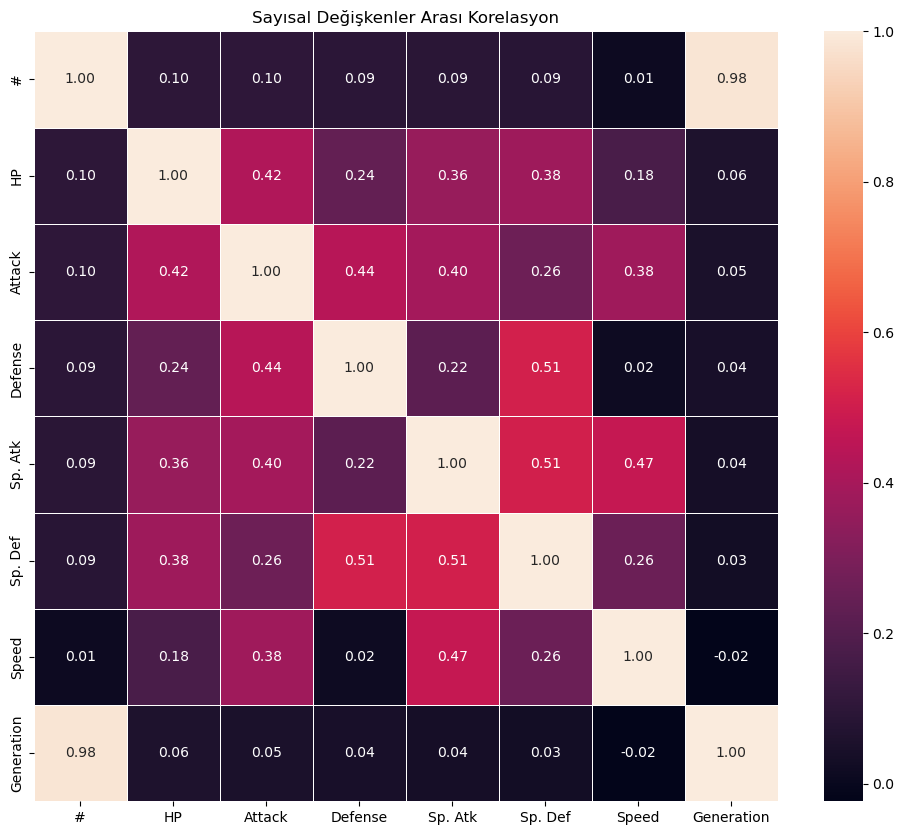

In [8]:
numeric_cols = data.select_dtypes(include=np.number).columns
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.show()


### Çizgi grafiği

Çizgi grafiği zaman serileri için çok kullanılır; ancak sıralı indeks üzerinden iki değişkeni karşılaştırmak için de hızlı bir ilk bakış sağlayabilir.


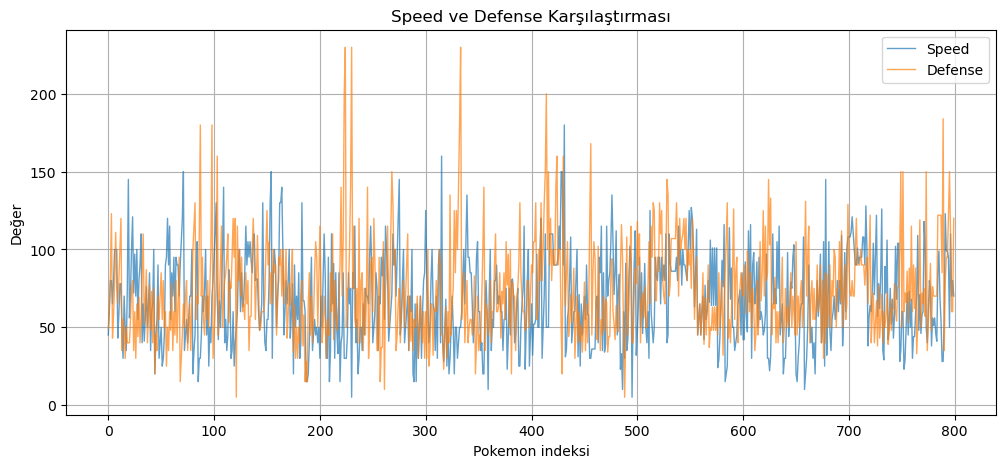

In [9]:
plt.figure(figsize=(12, 5))
data["Speed"].plot(label="Speed", linewidth=1, alpha=0.7)
data["Defense"].plot(label="Defense", linewidth=1, alpha=0.7)
plt.xlabel("Pokemon indeksi")
plt.ylabel("Değer")
plt.title("Speed ve Defense Karşılaştırması")
plt.legend()
plt.grid(True)
plt.show()


### Saçılım grafiği

Scatter plot, iki sayısal değişken arasındaki ilişkiyi gözlemlemek için kullanılır. Örneğin `Attack` ile `Defense` arasında belirgin bir ilişki var mı, buradan kontrol edebiliriz.


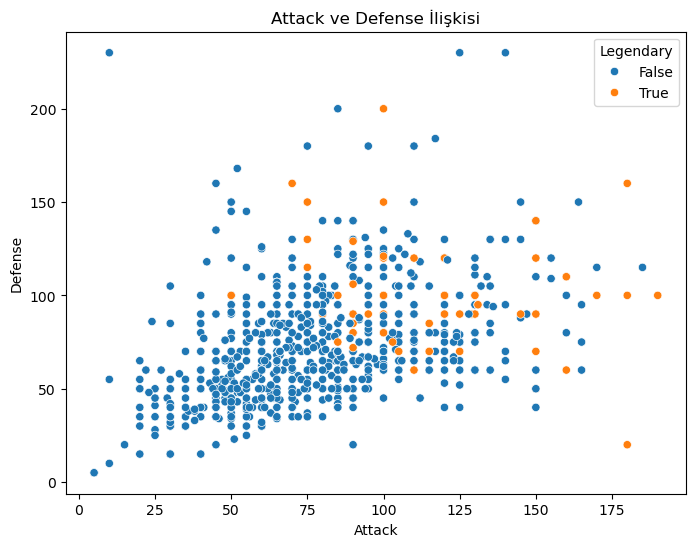

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x="Attack", y="Defense", hue="Legendary")
plt.title("Attack ve Defense İlişkisi")
plt.show()


### Histogram

Histogram, bir sayısal değişkenin hangi aralıklarda yoğunlaştığını gösterir.


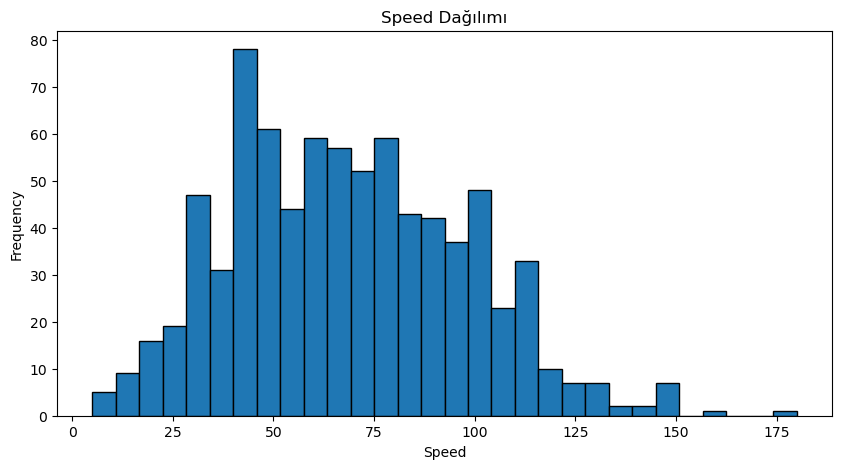

In [11]:
plt.figure(figsize=(10, 5))
data["Speed"].plot(kind="hist", bins=30, edgecolor="black")
plt.xlabel("Speed")
plt.title("Speed Dağılımı")
plt.show()


## 5. Python kısa tekrar

Makine öğrenmesi projelerinde yalnızca model kurmak yeterli değildir. Veri okuma, temizleme, dönüştürme ve sonuçları yorumlama aşamalarında temel Python bilgisi sürekli kullanılır.


### 5.1 Sözlükler

Sözlükler `key: value` mantığıyla çalışır. Kategorik eşleştirme, ayar tutma veya hızlı arama işlemlerinde çok kullanışlıdır.


In [12]:
type_mapping = {
    "Fire": "Ateş",
    "Water": "Su",
    "Grass": "Çimen",
    "Electric": "Elektrik"
}

print(type_mapping.keys())
print(type_mapping.values())
print("Fire karşılığı:", type_mapping["Fire"])

type_mapping["Psychic"] = "Psişik"  # yeni değer ekleme
print(type_mapping)


dict_keys(['Fire', 'Water', 'Grass', 'Electric'])
dict_values(['Ateş', 'Su', 'Çimen', 'Elektrik'])
Fire karşılığı: Ateş
{'Fire': 'Ateş', 'Water': 'Su', 'Grass': 'Çimen', 'Electric': 'Elektrik', 'Psychic': 'Psişik'}


### 5.2 Koşullu filtreleme

Pandas'ta koşullu filtreleme, satır seçmenin en pratik yollarından biridir.


In [13]:
# Attack değeri 120'den büyük olan ilk 5 Pokemon
strong_attackers = data[data["Attack"] > 120]
strong_attackers.head()


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
7,8,Mega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False
19,20,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,1,False
74,75,Machamp,Fighting,NaN,90,130,80,65,85,55,1,False
107,108,Kingler,Water,NaN,55,130,115,50,50,75,1,False
120,121,Rhydon,Ground,Rock,105,130,120,45,45,40,1,False


In [14]:
# Hem hızlı hem de saldırısı yüksek Pokemonlar
fast_and_strong = data[(data["Speed"] > 100) & (data["Attack"] > 100)]
fast_and_strong[["Name", "Type 1", "Attack", "Speed"]].head(10)


,Name,Type 1,Attack,Speed
19,Mega Beedrill,Bug,150,145
132,Scyther,Bug,110,105
137,Mega Pinsir,Bug,155,105
153,Aerodactyl,Rock,105,130
154,Mega Aerodactyl,Rock,135,150
162,Mewtwo,Psychic,110,130
163,Mega Mewtwo X,Psychic,190,130
164,Mega Mewtwo Y,Psychic,150,140
275,Mega Sceptile,Grass,110,145
349,Mega Sharpedo,Water,140,105


### 5.3 Döngüler

Döngüler, veri üzerinde tekrarlı işlem yapmamızı sağlar. Pandas'ta çoğu zaman vektörel işlemler tercih edilir; ama Python mantığını anlamak için döngüler hâlâ önemlidir.


In [15]:
for stat in ["HP", "Attack", "Defense", "Speed"]:
    print(f"{stat:8s} ortalaması: {data[stat].mean():.2f}")


HP       ortalaması: 69.26
Attack   ortalaması: 79.00
Defense  ortalaması: 73.84
Speed    ortalaması: 68.28


### 5.4 Fonksiyonlar

Fonksiyonlar tekrar eden işlemleri düzenli ve yeniden kullanılabilir hale getirir.


In [16]:
def summarize_column(df, column):
    # Seçilen sayısal sütun için temel istatistikleri döndürür.
    return {
        "ortalama": df[column].mean(),
        "medyan": df[column].median(),
        "minimum": df[column].min(),
        "maksimum": df[column].max()
    }

summarize_column(data, "Attack")


{'ortalama': np.float64(79.00125),
 'medyan': np.float64(75.0),
 'minimum': np.int64(5),
 'maksimum': np.int64(190)}

### 5.5 Lambda ve apply

`apply`, bir sütuna fonksiyon uygulamak için kullanılır. Basit işlemlerde lambda fonksiyonu yeterli olabilir.


In [21]:
data["Power_Level"] = data["Total"].apply(lambda x: "Yüksek" if x >= 500 else "Normal")
data[["Name", "Total", "Power_Level"]].head()


,Name,Total,Power_Level
0,Bulbasaur,318,Normal
1,Ivysaur,405,Normal
2,Venusaur,525,Yüksek
3,Mega Venusaur,625,Yüksek
4,Charmander,309,Normal


## 6. Veri temizleme ve düzenleme

Veri temizleme aşamasında sütun adları, veri tipleri, eksik değerler ve tutarsız kategoriler kontrol edilir. Model kalitesi çoğu zaman bu aşamanın kalitesine bağlıdır.


In [22]:
# Sütun adlarını daha kullanışlı hale getirelim
clean_data = data.copy()
clean_data.columns = (
    clean_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

clean_data.columns.tolist()


['#',
 'name',
 'type_1',
 'type_2',
 'hp',
 'attack',
 'defense',
 'sp._atk',
 'sp._def',
 'speed',
 'generation',
 'legendary',
 'total',
 'power_level']

In [23]:
# Eksik değer oranı
missing_ratio = (clean_data.isna().mean() * 100).sort_values(ascending=False)
missing_ratio[missing_ratio > 0]


type_2    48.250
name       0.125
dtype: float64

`type_2` sütununda eksik değer bulunması normaldir; çünkü her Pokémon'un ikinci tipi yoktur. Bu eksikleri "Yok" gibi açıklayıcı bir değerle doldurabiliriz.


In [24]:
if "type_2" in clean_data.columns:
    clean_data["type_2"] = clean_data["type_2"].fillna("Yok")

clean_data.head()


,#,name,type_1,type_2,hp,attack,defense,sp._atk,sp._def,speed,generation,legendary,total,power_level
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,318,Normal
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,405,Normal
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,525,Yüksek
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,625,Yüksek
4,5,Charmander,Fire,Yok,39,52,43,60,50,65,1,False,309,Normal


### Uç değer kontrolü

Boxplot, sayısal bir değişkendeki uç değerleri hızlı görmek için kullanılır.


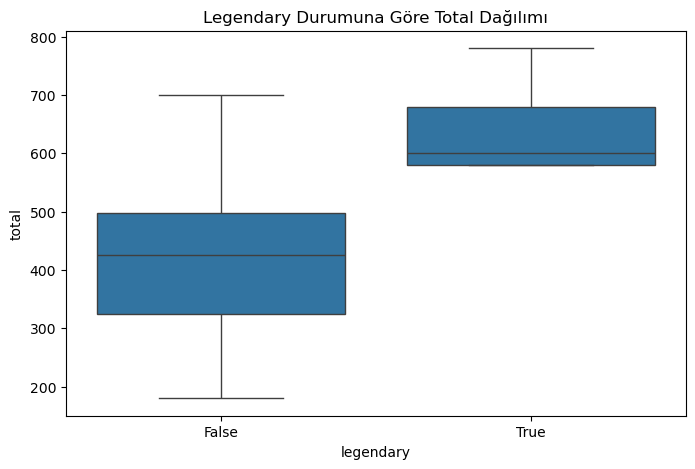

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_data, x="legendary", y="total")
plt.title("Legendary Durumuna Göre Total Dağılımı")
plt.show()


## 7. DataFrame işlemleri

Bu bölümde seçim, sıralama, yeni sütun oluşturma, gruplama ve yeniden şekillendirme gibi temel pandas işlemleri uygulanır.


In [26]:
# Belirli sütunları seçme
selected_columns = clean_data[["name", "type_1", "type_2", "hp", "attack", "defense", "speed", "legendary"]]
selected_columns.head()


,name,type_1,type_2,hp,attack,defense,speed,legendary
0,Bulbasaur,Grass,Poison,45,49,49,45,False
1,Ivysaur,Grass,Poison,60,62,63,60,False
2,Venusaur,Grass,Poison,80,82,83,80,False
3,Mega Venusaur,Grass,Poison,80,100,123,80,False
4,Charmander,Fire,Yok,39,52,43,65,False


In [27]:
# En yüksek toplam güce sahip ilk 10 Pokemon
top_total = clean_data.sort_values("total", ascending=False).head(10)
top_total[["name", "type_1", "total", "legendary"]]


,name,type_1,total,legendary
426,Mega Rayquaza,Dragon,780,True
164,Mega Mewtwo Y,Psychic,780,True
163,Mega Mewtwo X,Psychic,780,True
422,Primal Kyogre,Water,770,True
424,Primal Groudon,Ground,770,True
552,Arceus,Normal,720,True
712,Kyurem White Kyurem,Dragon,700,True
711,Kyurem Black Kyurem,Dragon,700,True
409,Mega Salamence,Dragon,700,False
413,Mega Metagross,Steel,700,False


In [28]:
# Gruplama: Type 1 bazında ortalama istatistikler
type_summary = (
    clean_data
    .groupby("type_1")[["hp", "attack", "defense", "speed", "total"]]
    .mean()
    .sort_values("total", ascending=False)
)

type_summary.head(10)


,hp,attack,defense,speed,total
type_1,,,,,
Dragon,83.312500,112.125000,86.375000,83.031250,550.531250
Steel,65.222222,92.703704,126.370370,55.259259,487.703704
Flying,70.750000,78.750000,66.250000,102.500000,485.000000
Psychic,70.631579,71.456140,67.684211,81.491228,475.947368
Fire,69.903846,84.769231,67.769231,74.442308,458.076923
Rock,65.363636,92.863636,100.795455,55.909091,453.750000
Dark,66.806452,88.387097,70.225806,76.161290,445.741935
Electric,59.795455,69.090909,66.295455,84.500000,443.409091
Ghost,64.437500,73.781250,81.187500,64.343750,439.562500


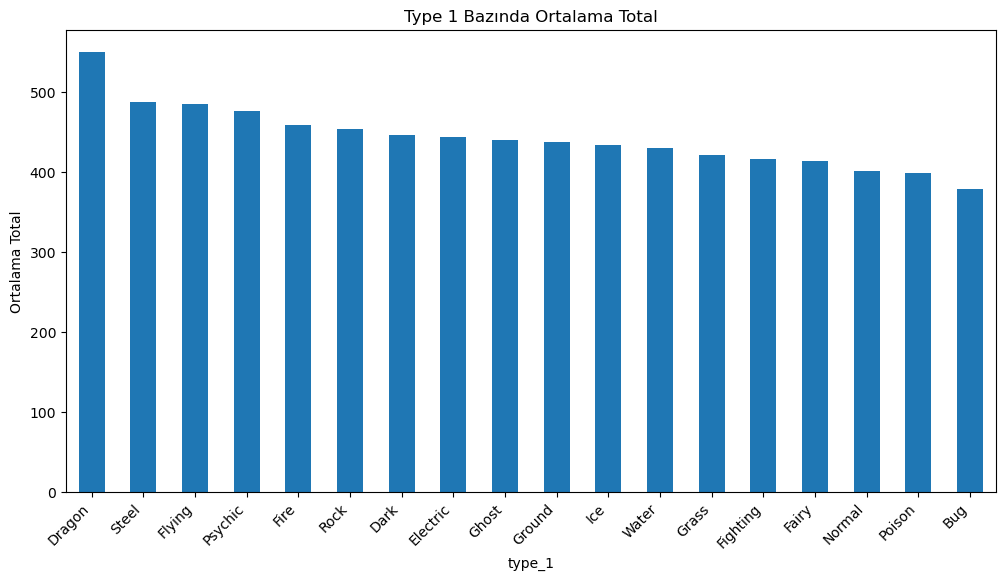

In [29]:
plt.figure(figsize=(12, 6))
type_summary["total"].plot(kind="bar")
plt.ylabel("Ortalama Total")
plt.title("Type 1 Bazında Ortalama Total")
plt.xticks(rotation=45, ha="right")
plt.show()


### Pivot tablo

Pivot tablolar, kategorilere göre özet tablo üretmek için kullanılır.


In [30]:
pivot_table = clean_data.pivot_table(
    values="total",
    index="type_1",
    columns="legendary",
    aggfunc="mean"
)

pivot_table.head(10)


legendary,False,True
type_1,,
Bug,378.927536,NaN
Dark,432.344828,640.000000
Dragon,476.850000,673.333333
Electric,429.750000,580.000000
Fairy,396.500000,680.000000
Fighting,416.444444,NaN
Fire,442.127660,608.000000
Flying,390.000000,580.000000
Ghost,423.533333,680.000000


### Melt ile uzun formata geçiş

Bazı grafik ve analiz işlemleri için veriyi geniş formattan uzun formata çevirmek gerekir. `melt` bu dönüşüm için kullanılır.


In [31]:
stat_columns = ["hp", "attack", "defense", "sp._atk", "sp._def", "speed"]

long_stats = clean_data.melt(
    id_vars=["name", "type_1", "legendary"],
    value_vars=stat_columns,
    var_name="stat",
    value_name="value"
)

long_stats.head()


,name,type_1,legendary,stat,value
0,Bulbasaur,Grass,False,hp,45
1,Ivysaur,Grass,False,hp,60
2,Venusaur,Grass,False,hp,80
3,Mega Venusaur,Grass,False,hp,80
4,Charmander,Fire,False,hp,39


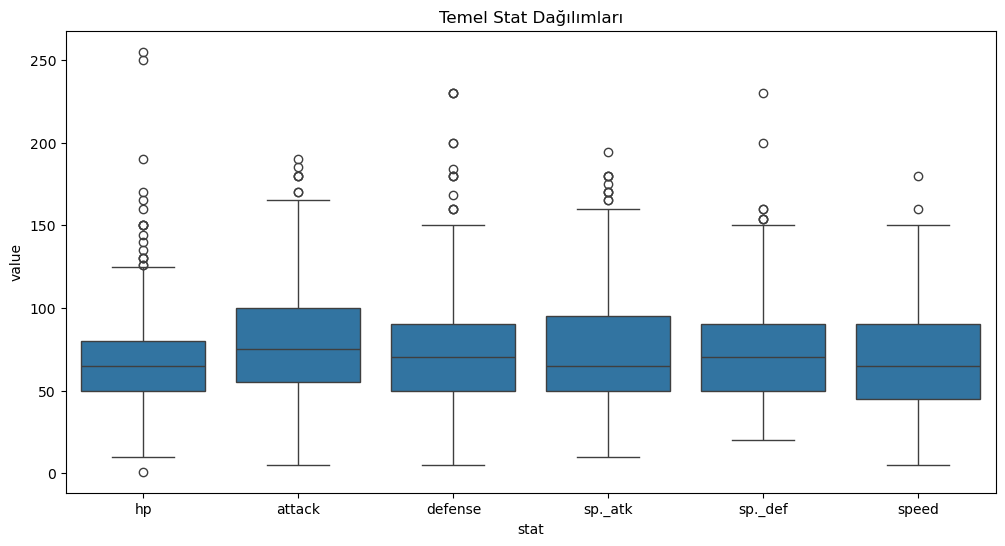

In [32]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=long_stats, x="stat", y="value")
plt.title("Temel Stat Dağılımları")
plt.show()


## 8. Makine öğrenmesine geçiş

Bu bölümde amaç, Pokémon'un `legendary` olup olmadığını sayısal özelliklerden tahmin eden basit bir sınıflandırma modeli kurmaktır. Bu örnek, makine öğrenmesi akışını görmek içindir; gerçek projelerde veri sızıntısı, model seçimi, hiperparametre ayarı ve daha ayrıntılı değerlendirme gerekir.

Temel akış:

1. Özellikleri (`X`) ve hedef değişkeni (`y`) belirle
2. Veriyi eğitim/test olarak ayır
3. Modeli eğitim verisiyle eğit
4. Test verisinde performansı ölç
5. Sonucu yorumla


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [34]:
feature_cols = ["hp", "attack", "defense", "sp._atk", "sp._def", "speed", "generation"]

X = clean_data[feature_cols]
y = clean_data["legendary"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)


Eğitim seti: (640, 7)
Test seti: (160, 7)


In [35]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.3f}")
print("\nSınıflandırma raporu:\n")
print(classification_report(y_test, predictions, target_names=["Normal", "Legendary"]))


Accuracy: 0.931

Sınıflandırma raporu:

              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       147
   Legendary       0.75      0.23      0.35        13

    accuracy                           0.93       160
   macro avg       0.84      0.61      0.66       160
weighted avg       0.92      0.93      0.91       160



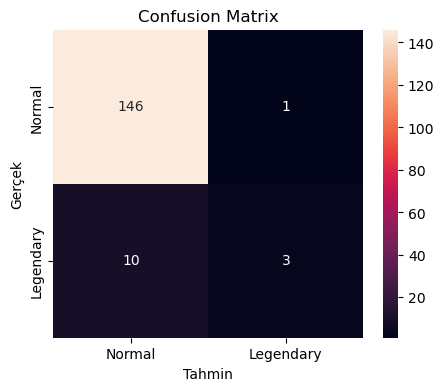

In [36]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["Normal", "Legendary"], yticklabels=["Normal", "Legendary"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()


### Özellik önemleri

Random Forest gibi ağaç tabanlı modeller, hangi değişkenlerin tahminde daha etkili olduğuna dair pratik bir gösterge sunabilir. Bu değerler kesin nedensellik anlamına gelmez; yalnızca modelin kararlarında hangi özellikleri daha çok kullandığını gösterir.


In [37]:
feature_importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
feature_importance


sp._atk       0.204334
speed         0.200910
sp._def       0.200260
hp            0.165822
attack        0.122669
defense       0.080934
generation    0.025071
dtype: float64

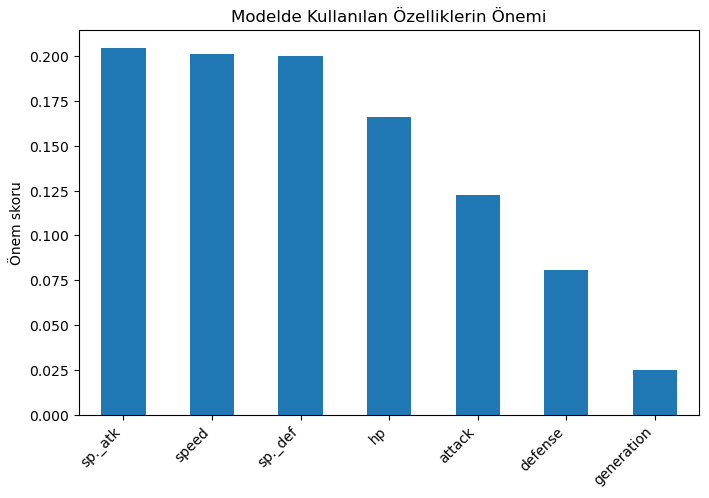

In [38]:
plt.figure(figsize=(8, 5))
feature_importance.plot(kind="bar")
plt.ylabel("Önem skoru")
plt.title("Modelde Kullanılan Özelliklerin Önemi")
plt.xticks(rotation=45, ha="right")
plt.show()
